In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Step 1: Read the image and convert the image into RGB
image = cv2.imread('c:\\Users\\Neo\\Pictures\\cheetah.jpg')  # Replace with your image path
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

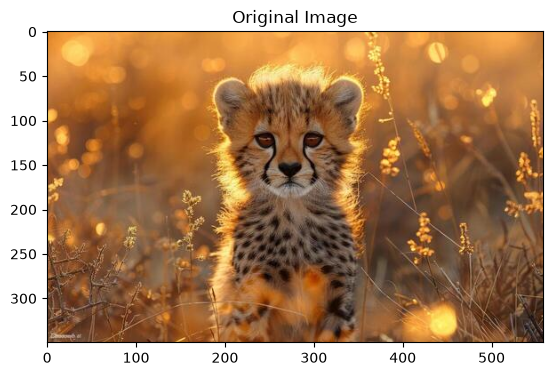

In [4]:
# Step 2: Display the original image
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('on')
plt.show()

In [15]:
# Step 4: Set the pixels to display the ROI (Region of Interest)
# Define the coordinates for the Region of Interest (ROI)
# (startY:endY, startX:endX)
roi = image[20:420, 150:400]  # ROI coordinates (adjust as needed)

# Create a blank mask of the same size as the original image
mask = np.zeros_like(image)

# Place the ROI on the mask
mask[20:420, 150:400] = roi

In [16]:
# Step 5: Perform bitwise conjunction of the two arrays using bitwise_and
segmented_roi = cv2.bitwise_and(image, mask)

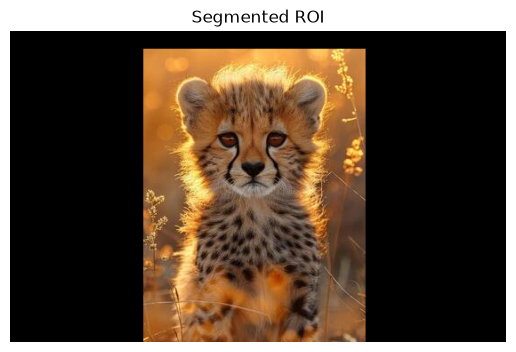

In [17]:
# Step 6: Display the segmented ROI from the image
segmented_roi_rgb = cv2.cvtColor(segmented_roi, cv2.COLOR_BGR2RGB)
plt.imshow(segmented_roi_rgb)
plt.title("Segmented ROI")
plt.axis('off')
plt.show()


In [47]:
# Step 1: Read the image and convert it to RGB for displaying
image = cv2.imread('your_image_1.jpg')  # Replace with your actual image file path
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

(-0.5, 745.5, 320.5, -0.5)

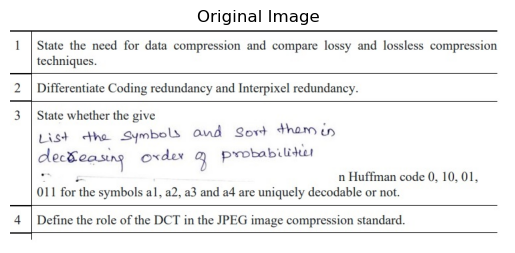

In [54]:
# Original Image
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')

In [48]:
# Step 2: Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale


In [49]:
# Step 3: Apply Gaussian blur to reduce noise
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)  # Apply Gaussian blur (5x5 kernel)

In [50]:
# Step 5: Use Canny edge detector to find edges
edges = cv2.Canny(blurred_image, 50, 150)  # Detect edges using Canny (thresholds 50 and 150)

(-0.5, 745.5, 320.5, -0.5)

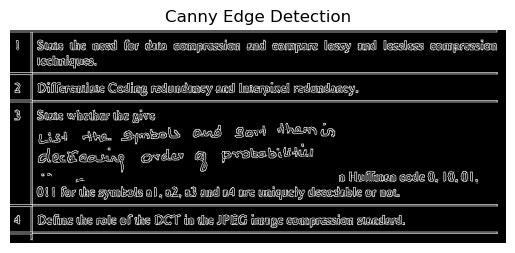

In [55]:
# Canny Edge Detection
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')

In [51]:
# Step 6: Find contours in the edged image
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [63]:
# Step 7: Filter contours based on area and draw bounding boxes
result_image = image.copy()  # Create a copy of the original image to draw bounding boxes
for contour in contours:
    if cv2.contourArea(contour) > 50:  # Filter out small areas
        x, y, w, h = cv2.boundingRect(contour)  # Get the bounding box for the contour
        cv2.rectangle(result_image, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Draw the rectangle

(-0.5, 745.5, 320.5, -0.5)

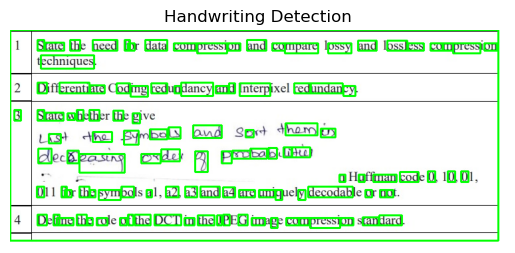

In [64]:
# Handwriting Detection Result
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.title("Handwriting Detection")
plt.axis('off')

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [27]:
config_file = 'deploy.prototxt'  # Path to the config file
weights = 'mobilenet_iter_73000.caffemodel'  # Path to the weights file

In [28]:
# Step 2: Use a pretrained DNN model (MobileNet-SSD v3)
net = cv2.dnn.readNetFromCaffe(config_file, weights)

In [29]:
# Step 4: Create a class label and print the same
class_labels = {0: 'background', 1: 'aeroplane', 2: 'bicycle', 3: 'bird', 4: 'boat',
                5: 'bottle', 6: 'bus', 7: 'car', 8: 'cat', 9: 'chair', 10: 'cow', 11: 'diningtable',
                12: 'dog', 13: 'horse', 14: 'motorbike', 15: 'person', 16: 'pottedplant', 17: 'sheep',
                18: 'sofa', 19: 'train', 20: 'tvmonitor'}

In [30]:
# Step 5: Read the image
image = cv2.imread('download.webp')  # Replace with your image path
(h, w) = image.shape[:2]

In [31]:
# Convert image to RGB for displaying with Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [32]:
# Create a blob for DNN processing
blob = cv2.dnn.blobFromImage(image, 0.007843, (300, 300), 127.5)

In [33]:
# Step 6: Set the model and threshold to 0.5
net.setInput(blob)
detections = net.forward()

In [36]:
# Step 7: Flatten the index, confidence
for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]

    if confidence > 0.5:  # Confidence threshold
        index = int(detections[0, 0, i, 1])  # Get class index
        label = class_labels[index]  # Get label name
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = box.astype("int")
# Step 8: Draw rectangles and labels on the image
        cv2.rectangle(image_rgb, (startX, startY), (endX, endY), (0, 255, 0), 2)
        cv2.putText(image_rgb, label, (startX, startY - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

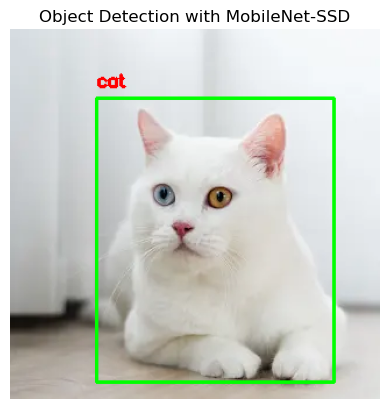

In [37]:
# Step 9: Display the image using Matplotlib
plt.imshow(image_rgb)
plt.title("Object Detection with MobileNet-SSD")
plt.axis("off")
plt.show()

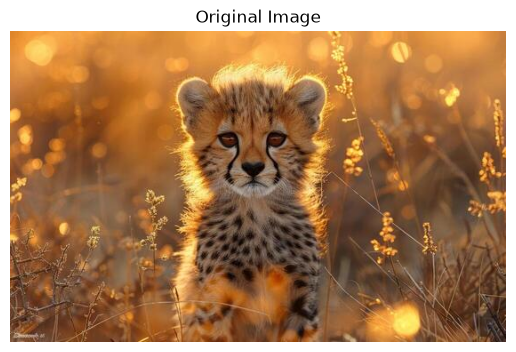

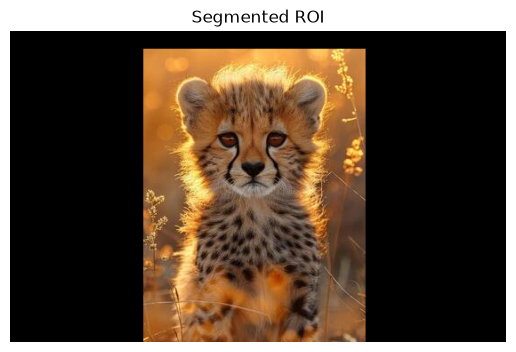

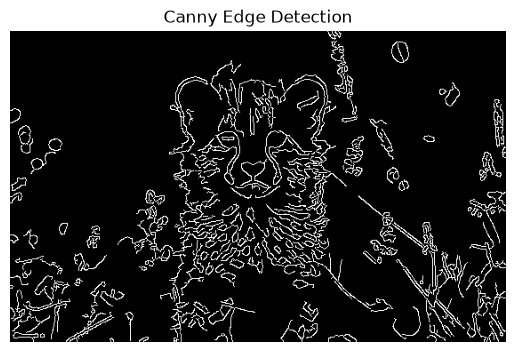

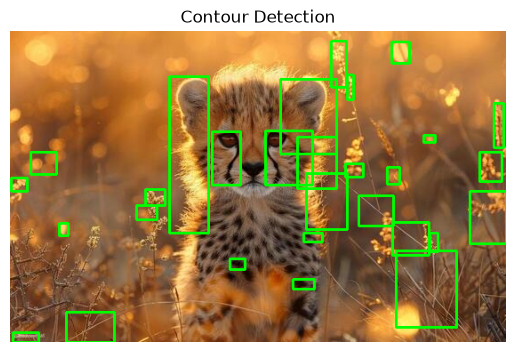

AttributeError: module 'cv2.dnn' has no attribute 'readNetFromCaffe'

In [ ]:
`````````import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================
# PART 1: ROI SEGMENTATION
# =========================

image = cv2.imread('c:\\Users\\Neo\\Pictures\\cheetah.jpg')

if image is None:
    print("Error: cheetah.jpg not found")
    exit()

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

# ROI
roi = image[20:420, 150:400]

mask = np.zeros_like(image)
mask[20:420, 150:400] = roi

segmented = cv2.bitwise_and(image, mask)

plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
plt.title("Segmented ROI")
plt.axis('off')
plt.show()


# =========================
# PART 2: EDGE DETECTION
# =========================

image = cv2.imread('c:\\Users\\Neo\\Pictures\\cheetah.jpg')

if image is None:
    print("Error: cheetah.jpg not found")
    exit()

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.show()

contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

result = image.copy()

for c in contours:
    if cv2.contourArea(c) > 50:
        x, y, w, h = cv2.boundingRect(c)
        cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Contour Detection")
plt.axis('off')
plt.show()


# =========================
# PART 3: OBJECT DETECTION (SAFE VERSION)
# =========================

config_file = 'deploy.prototxt'
weights_file = 'mobilenet_iter_73000.caffemodel'

# If model files NOT found → skip safely
if not os.path.exists(config_file) or not os.path.exists(weights_file):
    print("⚠️ Model files not found → Skipping Object Detection part")
else:
    net = cv2.dnn.readNetFromCaffe(config_file, weights_file)

    class_labels = {
        0:'background',1:'aeroplane',2:'bicycle',3:'bird',4:'boat',
        5:'bottle',6:'bus',7:'car',8:'cat',9:'chair',10:'cow',
        11:'diningtable',12:'dog',13:'horse',14:'motorbike',
        15:'person',16:'pottedplant',17:'sheep',18:'sofa',
        19:'train',20:'tvmonitor'
    }

    image = cv2.imread('c:\\Users\\Neo\\Pictures\\cheetah.jpg')

    if image is None:
        print("Error: image.jpeg not found")
        exit()

    (h, w) = image.shape[:2]

    blob = cv2.dnn.blobFromImage(image, 0.007843, (300, 300), 127.5)
    net.setInput(blob)
    detections = net.forward()

    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]

        if confidence > 0.5:
            idx = int(detections[0, 0, i, 1])
            label = class_labels.get(idx, "Unknown")

            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")

            cv2.rectangle(image, (startX, startY), (endX, endY), (0, 255, 0), 2)
            cv2.putText(image, label, (startX, startY - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Object Detection (MobileNet-SSD)")
    plt.axis('off')
    plt.show()`````````